## ⚡ Electricity & CO₂ Emissions Analysis

This analysis explores the relationship between global electricity production, CO₂ emissions, and economic indicators.

The goal is to identify:
- Key drivers of CO₂ emissions  
- The role of renewable energy  
- The relationship between economic growth and electricity access  

#### 🧾 IMPORT LIBRARY

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

#### 📥 DATA LOADING

In [4]:
df = pd.read_csv("global-data-on-sustainable-energy.csv")
df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


### 🔍 DATA OVERVIEW

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7   Electricity from fossil fuels (TW

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Latitude,Longitude
count,3649.000000,3639.000000,3480.000000,2718.000000,1.560000e+03,3455.000000,3628.000000,3523.000000,3628.000000,3607.000000,3649.000000,3442.000000,3.221000e+03,1512.000000,3332.000000,3367.000000,3.648000e+03,3648.000000,3648.000000
mean,2010.038367,78.933702,63.255287,113.137498,9.422400e+07,32.638165,70.365003,13.450190,23.968010,36.801182,25743.981745,5.307345,1.598665e+05,11.986707,3.441610,13283.774348,6.332135e+05,18.246388,14.822695
std,6.054228,30.275541,39.043658,244.167256,2.981544e+08,29.894901,348.051866,73.006623,104.431085,34.314884,34773.221366,3.532020,7.736611e+05,14.994644,5.686720,19709.866716,1.585519e+06,24.159232,66.348148
min,2000.000000,1.252269,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.110000,1.000000e+01,0.000000,-62.075920,111.927225,2.100000e+01,-40.900557,-175.198242
25%,2005.000000,59.800890,23.175000,3.540000,2.600000e+05,6.515000,0.290000,0.000000,0.040000,2.877847,3116.737300,3.170000,2.020000e+03,2.137095,1.383302,1337.813437,2.571300e+04,3.202778,-11.779889
50%,2010.000000,98.361570,83.150000,32.910000,5.665000e+06,23.300000,2.970000,0.000000,1.470000,27.865068,13120.570000,4.300000,1.050000e+04,6.290766,3.559855,4578.633208,1.176000e+05,17.189877,19.145136
75%,2015.000000,100.000000,100.000000,112.210000,5.534750e+07,55.245000,26.837500,0.000000,9.600000,64.403792,33892.780000,6.027500,6.058000e+04,16.841638,5.830099,15768.615365,5.131200e+05,38.969719,46.199616
max,2020.000000,100.000000,100.000000,3060.190000,5.202310e+09,96.040000,5184.130000,809.410000,2184.940000,100.000010,262585.700000,32.570000,1.070722e+07,86.836586,123.139555,123514.196700,9.984670e+06,64.963051,178.065032


The dataset includes:
- Categorical variables: Name, Platform, Genre, Publisher  
- Numerical variables: Sales across regions and globally  
- Year of release

#### 🧹 DATA CLEANING

In [6]:
# rename columns
df.columns = df.columns.str.lower().str.replace(' ', '_')

# drop missing values
df = df.dropna(subset=[
    'electricity_from_fossil_fuels_(twh)',
    'electricity_from_renewables_(twh)',
    'value_co2_emissions_kt_by_country'
])
# remove duplicates
df = df.drop_duplicates()

✅ Cleaning Summary
- Standardized column names into snake_case  
- Removed missing values to ensure data consistency  
- Verified data types for accurate analysis  
- No duplicate data found  

### ⚙️ Feature Engineering


In [7]:
df['total_electricity'] = (
    df['electricity_from_fossil_fuels_(twh)'] +
    df['electricity_from_renewables_(twh)'] +
    df['electricity_from_nuclear_(twh)']
)

df['fossil_ratio'] = df['electricity_from_fossil_fuels_(twh)'] / df['total_electricity']

⚙️ Feature Engineering Summary
- Created total electricity production (fossil + renewable + nuclear)  
- Created fossil fuel ratio to measure energy dependency  

#### 📊 EXPLORATORY DATA ANALYSIS (EDA)

In [14]:
# 🎨 GLOBAL STYLE CONFIG

# background & palette
BG_COLOR = '#0f223a'
MAIN_COLOR = '#5DADE2'
GREEN = '#58D68D'
PURPLE = '#AF7AC5'
HIGHLIGHT = '#00E5FF'
GRID_COLOR = '#2c3e50'
TEXT_COLOR = 'white'

##### ⚡ 1. Energy Mix by Country

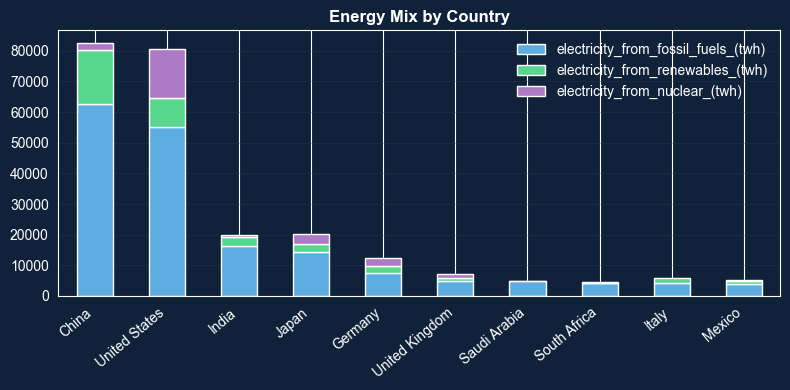

In [23]:
fig, ax = plt.subplots(figsize=(8,4))

top_countries.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=[MAIN_COLOR, GREEN, PURPLE]
)

# 🎨 background (ikut global)
ax.set_facecolor(BG_COLOR)
fig.patch.set_facecolor(BG_COLOR)

# title
ax.set_title('Energy Mix by Country', color=TEXT_COLOR, fontsize=12, weight='bold')

# grid
ax.grid(axis='y', color=GRID_COLOR, alpha=0.3)

# ticks
ax.tick_params(colors=TEXT_COLOR)
plt.xticks(rotation=40, ha='right')

# legend
legend = ax.legend(frameon=False)
for text in legend.get_texts():
    text.set_color(TEXT_COLOR)

# clean axis label
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

💡 Insight

The energy mix across top electricity-producing countries shows a strong dominance of fossil fuels, particularly in countries like China and the United States.  

While renewable energy is present, it generally represents a smaller share of total electricity production, and nuclear energy contributes even less in most countries.  

This indicates that despite ongoing efforts toward clean energy, the global energy system remains heavily dependent on fossil fuels, highlighting the slow pace of energy transition.

##### 🔥 2. Fossil Fuel vs CO₂ Emissions

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_20636\1113637453.py:33: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


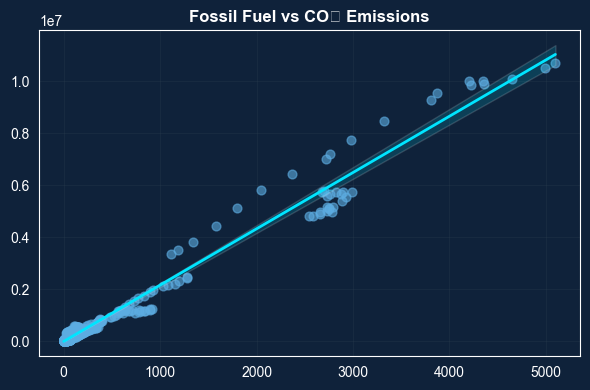

In [22]:
plt.figure(figsize=(6,4))

ax = sns.regplot(
    data=df,
    x='electricity_from_fossil_fuels_(twh)',
    y='value_co2_emissions_kt_by_country',
    scatter_kws={
        'color': MAIN_COLOR,
        'alpha': 0.6,
        's': 40
    },
    line_kws={
        'color': HIGHLIGHT,
        'linewidth': 2
    }
)

# 🎨 background
ax.set_facecolor(BG_COLOR)
plt.gcf().patch.set_facecolor(BG_COLOR)

# grid
ax.grid(color=GRID_COLOR, alpha=0.3)

# text
ax.set_title('Fossil Fuel vs CO₂ Emissions', color=TEXT_COLOR, fontsize=12, weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')

# ticks
ax.tick_params(colors=TEXT_COLOR)

plt.tight_layout()
plt.show()

💡 Insight

There is a strong positive relationship between fossil fuel electricity production and CO₂ emissions.

Countries that generate more electricity from fossil fuels tend to produce significantly higher emissions.  
This confirms that fossil fuel dependency is the primary driver of global CO₂ emissions.

##### 🌱 3. Renewable Energy vs CO₂

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_20636\4091792237.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\VICTUS\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


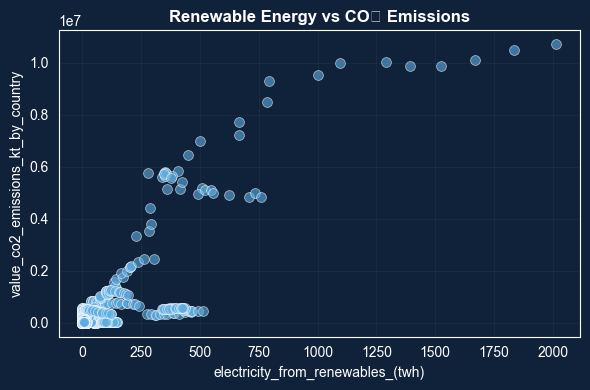

In [21]:
fig, ax = plt.subplots(figsize=(6,4))

sns.scatterplot(
    data=df,
    x='electricity_from_renewables_(twh)',
    y='value_co2_emissions_kt_by_country',
    color=MAIN_COLOR,
    alpha=0.6,
    s=50,
    ax=ax
)

# 🎨 background
ax.set_facecolor(BG_COLOR)
fig.patch.set_facecolor(BG_COLOR)

# grid
ax.grid(color=GRID_COLOR, alpha=0.3)

# title
ax.set_title('Renewable Energy vs CO₂ Emissions', color=TEXT_COLOR, fontsize=12, weight='bold')

# ticks
ax.tick_params(colors=TEXT_COLOR)

plt.tight_layout()
plt.show()

💡 Insight

Renewable energy shows a weaker relationship with CO₂ emissions compared to fossil fuels.  

This suggests that current renewable adoption levels are not yet sufficient to significantly offset emissions at a global scale.

##### 📈4. GDP vs Electricity Access

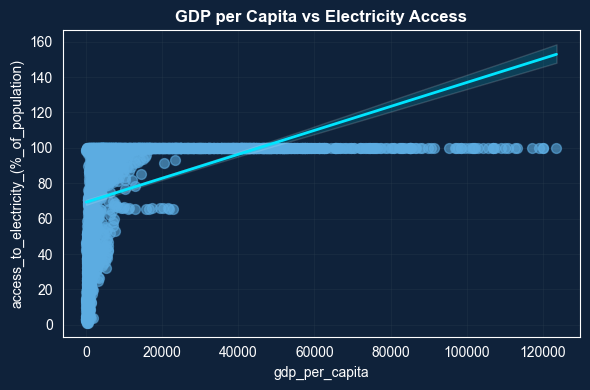

In [28]:
fig, ax = plt.subplots(figsize=(6,4))

sns.regplot(
    data=df,
    x='gdp_per_capita',
    y='access_to_electricity_(%_of_population)',
    scatter_kws={
        'color': MAIN_COLOR,
        'alpha': 0.6,
        's': 50
    },
    line_kws={
        'color': HIGHLIGHT,
        'linewidth': 2
    },
    ax=ax
)

# 🎨 background
ax.set_facecolor(BG_COLOR)
fig.patch.set_facecolor(BG_COLOR)

# grid
ax.grid(color=GRID_COLOR, alpha=0.3)

# title
ax.set_title(
    'GDP per Capita vs Electricity Access',
    color=TEXT_COLOR,
    fontsize=12,
    weight='bold'
)

# ticks
ax.tick_params(colors=TEXT_COLOR)

plt.tight_layout()
plt.show()

💡 Insight

There is a clear positive correlation between GDP per capita and electricity access.  

Countries with stronger economies tend to achieve near-universal electricity access, while lower-income countries continue to face significant energy access gaps.

##### 🌍 5. Top 10 CO₂ Emitting Countries

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_20636\1388999612.py:29: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\VICTUS\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


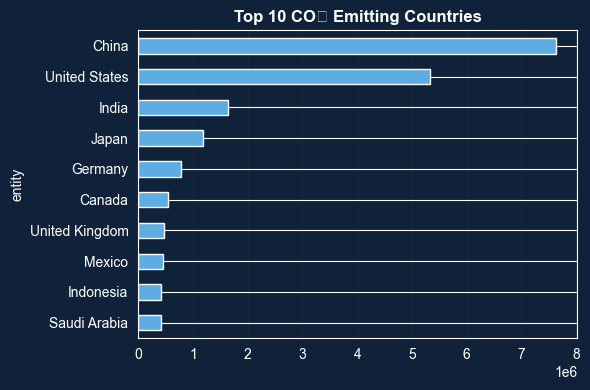

In [54]:
top_emitters = df.groupby('entity')['value_co2_emissions_kt_by_country'].mean().nlargest(10)

fig, ax = plt.subplots(figsize=(6,4))

top_emitters.sort_values().plot(
    kind='barh',
    ax=ax,
    color=MAIN_COLOR
)

# 🎨 background
ax.set_facecolor(BG_COLOR)
fig.patch.set_facecolor(BG_COLOR)

# grid
ax.grid(axis='x', color=GRID_COLOR, alpha=0.3)

# title
ax.set_title(
    'Top 10 CO₂ Emitting Countries',
    color=TEXT_COLOR,
    fontsize=12,
    weight='bold'
)

# ticks
ax.tick_params(colors=TEXT_COLOR)

plt.tight_layout()
plt.show()

💡 Insight

A small number of countries contribute disproportionately to global CO₂ emissions.

This indicates that targeting high-emission countries could have a significant global impact on emission reduction efforts.

##### 📊 6. Top Countries by Renewable Energy

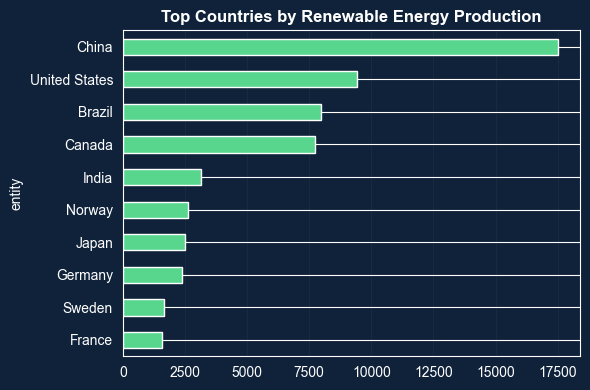

In [55]:
top_renewable = df.groupby('entity')['electricity_from_renewables_(twh)'].sum().nlargest(10)

fig, ax = plt.subplots(figsize=(6,4))

top_renewable.sort_values().plot(
    kind='barh',
    ax=ax,
    color=GREEN
)

# 🎨 background
ax.set_facecolor(BG_COLOR)
fig.patch.set_facecolor(BG_COLOR)

# grid
ax.grid(axis='x', color=GRID_COLOR, alpha=0.3)

# title
ax.set_title(
    'Top Countries by Renewable Energy Production',
    color=TEXT_COLOR,
    fontsize=12,
    weight='bold'
)

# ticks
ax.tick_params(colors=TEXT_COLOR)

plt.tight_layout()
plt.show()

💡 Insight

A small group of countries dominates renewable energy production globally.  
However, high renewable output does not necessarily translate into low emissions, as many of these countries still rely heavily on fossil fuels.

This suggests that renewable energy adoption alone is not sufficient without reducing fossil fuel dependency.

##### ⚡ 7. Top Countries by Fossil Fuel Usage

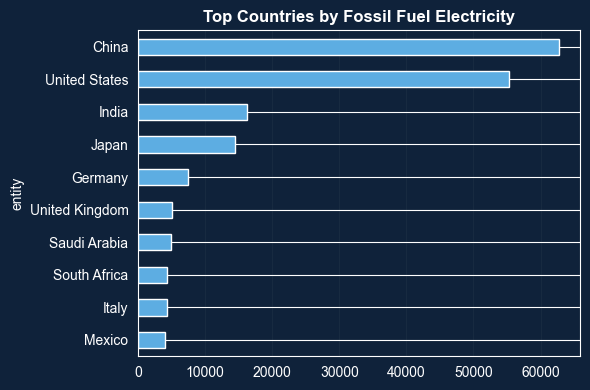

In [56]:
top_fossil = df.groupby('entity')['electricity_from_fossil_fuels_(twh)'].sum().nlargest(10)

fig, ax = plt.subplots(figsize=(6,4))

top_fossil.sort_values().plot(
    kind='barh',
    ax=ax,
    color=MAIN_COLOR
)

# 🎨 background
ax.set_facecolor(BG_COLOR)
fig.patch.set_facecolor(BG_COLOR)

# grid
ax.grid(axis='x', color=GRID_COLOR, alpha=0.3)

# title
ax.set_title(
    'Top Countries by Fossil Fuel Electricity',
    color=TEXT_COLOR,
    fontsize=12,
    weight='bold'
)

# ticks
ax.tick_params(colors=TEXT_COLOR)

plt.tight_layout()
plt.show()

💡 Insight

Countries with the highest fossil fuel electricity production consistently rank among the largest CO₂ emitters.  

This reinforces the role of fossil fuels as the primary driver of global emissions and highlights the urgency of transitioning to cleaner energy sources.

##### 🌍 8. Countries with Lowest Electricity Access

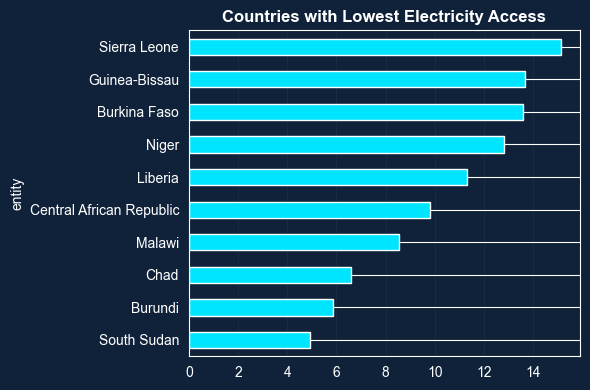

In [51]:
low_access = df.groupby('entity')['access_to_electricity_(%_of_population)'].mean().nsmallest(10)
fig, ax = plt.subplots(figsize=(6,4))

low_access.plot(
    kind='barh',
    ax=ax,
    color=HIGHLIGHT  # beda warna biar langsung kelihatan "issue"
)

# 🎨 background
ax.set_facecolor(BG_COLOR)
fig.patch.set_facecolor(BG_COLOR)

# grid
ax.grid(axis='x', color=GRID_COLOR, alpha=0.3)

# title
ax.set_title(
    'Countries with Lowest Electricity Access',
    color=TEXT_COLOR,
    fontsize=12,
    weight='bold'
)

# ticks
ax.tick_params(colors=TEXT_COLOR)

plt.tight_layout()
plt.show()

💡 Insight

Countries with the lowest electricity access are predominantly developing nations, reflecting significant global energy inequality.  

This indicates that improving electricity access remains a critical challenge, particularly in regions with limited infrastructure and economic resources.

##### 💰 9. GDP per Capita (Top Countries)

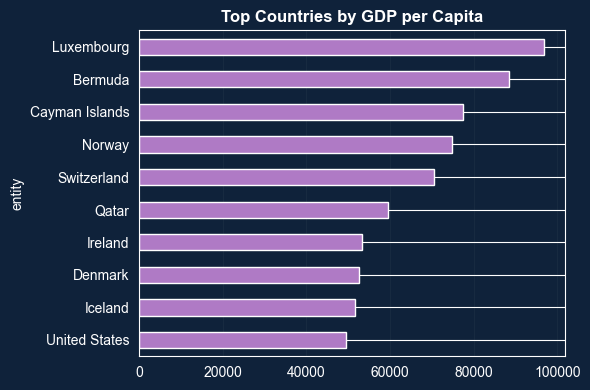

In [57]:
top_gdp = df.groupby('entity')['gdp_per_capita'].mean().nlargest(10)
fig, ax = plt.subplots(figsize=(6,4))
top_gdp.sort_values().plot(
    kind='barh',
    ax=ax,
    color=PURPLE  # beda dari energy → represent economic factor
)

# 🎨 background
ax.set_facecolor(BG_COLOR)
fig.patch.set_facecolor(BG_COLOR)

# grid
ax.grid(axis='x', color=GRID_COLOR, alpha=0.3)

# title
ax.set_title(
    'Top Countries by GDP per Capita',
    color=TEXT_COLOR,
    fontsize=12,
    weight='bold'
)

# ticks
ax.tick_params(colors=TEXT_COLOR)

plt.tight_layout()
plt.show()

💡 Insight

Higher GDP per capita is strongly associated with better infrastructure and energy systems.  

This suggests that economic development plays a crucial role in enabling both widespread electricity access and investment in cleaner energy technologies.

## 🎯 Conclusion

- Fossil fuel dependency is the main driver of CO₂ emissions  
- Renewable energy adoption is growing but not yet dominant  
- Economic strength plays a critical role in electricity accessibility  
- The global energy transition remains uneven across countries  

💡 A balanced strategy is required to improve energy access while reducing emissions.

## 🎯 Final Insight

The analysis shows that fossil fuel dependency remains the primary driver of global CO₂ emissions.  

Although renewable energy adoption is increasing, it has not yet reached a scale sufficient to significantly reduce emissions.  

Additionally, economic factors play a critical role, where countries with higher GDP per capita tend to have better electricity access and cleaner energy systems.  

This indicates that achieving a sustainable energy transition requires not only technological change, but also economic and infrastructure development.